In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
dirs <- c(
  paste0(indir,"/01_hmCG_open_peak/"),
  paste0(indir,"/01_hmCG_close_peak/"),
  paste0(indir,"/01_mCG_close_peak/"),
  paste0(indir,"/01_mCG_open_peak/")
)

dirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak/" 
[2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak/"
[3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak/" 
[4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak/"

In [2]:
result <- data.frame(
  subclass = character(),
  mean_diff = numeric(),
  modification = character(),
  statement = character(),
  stringsAsFactors = FALSE
)

In [3]:
result

subclass,mean_diff,modification,statement
<chr>,<dbl>,<chr>,<chr>


In [ ]:
basename(paste0(indir,"/01_hmCG_open_peak/"))

[1] "01_hmCG_open_peak"

In [5]:
for (dir in dirs) {
  dir_name <- basename(dir)
  modification <- sub("01_(.*)_(open|close)_peak", "\\1", dir_name)
  statement <- sub("01_(.*)_(open|close)_peak", "\\2", dir_name)
#   modification_clean <- gsub("G", "", modification)
  
  files <- list.files(dir, pattern = "\\.tmp$", full.names = TRUE)
  subclasses <- unique(sub("_(old|young)_(5hmCG|5mCG)\\.mm10\\.tmp$", "", basename(files)))
  
  for (subclass in subclasses) {
    old_file <- file.path(dir, paste0(subclass, "_old_5", modification, ".mm10.tmp"))
    young_file <- file.path(dir, paste0(subclass, "_young_5", modification, ".mm10.tmp"))
    
    if (!file.exists(old_file) || !file.exists(young_file)) {
      cat("Skipping missing files for subclass:", subclass, "\n")
      next
    }
    
    old_data <- read.table(old_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
    young_data <- read.table(young_file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)
    old_data_filtered <- old_data[!is.na(old_data[, 2]), ]
    young_data_filtered <- young_data[!is.na(young_data[, 2]), ]
    common_ids <- intersect(old_data_filtered[, 1], young_data_filtered[, 1])
    old_data_final <- old_data_filtered[old_data_filtered[, 1] %in% common_ids, ]
    young_data_final <- young_data_filtered[young_data_filtered[, 1] %in% common_ids, ]
    old_data_final <- old_data_final[match(common_ids, old_data_final[, 1]), ]
    young_data_final <- young_data_final[match(common_ids, young_data_final[, 1]), ]
    
    if (!identical(old_data_final$peak, young_data_final$peak)) {
      stop(paste("The peak columns in", old_file, "and", young_file, "do not match."))
    }
    
    mean_diff <- mean(old_data_final$Mean_ratio - young_data_final$Mean_ratio)
    result <- rbind(result, data.frame(
      subclass = subclass,
      mean_diff = mean_diff,
      modification = modification,
      statement = statement
    ))
  }
}

In [6]:
result

subclass,mean_diff,modification,statement
<chr>,<dbl>,<chr>,<chr>
ACB-BST-FS.D1.Gaba,0.016075136,hmCG,open
Astro-TE.NN,0.035722004,hmCG,open
CA1-ProS.Glut,0.034191654,hmCG,open
CA3.Glut,0.032182198,hmCG,open
CLA-EPd-CTX.Car3.Glut,0.029691279,hmCG,open
DG.Glut,0.037684114,hmCG,open
IT.AON-TT-DP.Glut,0.026698650,hmCG,open
L2.3.IT.CTX.Glut,0.031565975,hmCG,open
L2.3.IT.RSP.Glut,0.025904283,hmCG,open


In [7]:
library(ggplot2)
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [8]:
unique(result$subclass)

[1] "ACB-BST-FS.D1.Gaba"    "Astro-TE.NN"           "CA1-ProS.Glut"        
 [4] "CA3.Glut"              "CLA-EPd-CTX.Car3.Glut" "DG.Glut"              
 [7] "IT.AON-TT-DP.Glut"     "L2.3.IT.CTX.Glut"      "L2.3.IT.RSP.Glut"     
[10] "L4.5.IT.CTX.Glut"      "L5.ET.CTX.Glut"        "L5.IT.CTX.Glut"       
[13] "L5.NP.CTX.Glut"        "L6.CT.CTX.Glut"        "Lamp5.Gaba"           
[16] "Microglia.NN"          "OB-in.Frmd7.Gaba"      "OB-out.Frmd7.Gaba"    
[19] "OB.Eomes.Ms4a15.Glut"  "OEC.NN"                "Oligo.NN"             
[22] "OPC.NN"                "Pvalb.Gaba"            "Sncg.Gaba"            
[25] "STR.D1.Gaba"           "STR.D1.Sema5a.Gaba"    "STR.D2.Gaba"

In [ ]:
c('ACB-BST-FS D1 Gaba','Astro-TE NN','CA1-ProS Glut','CA3 Glut','CLA-EPd-CTX Car3 Glut','DG Glut','IT AON-TT-DP Glut','L2/3 IT CTX Glut',
 'L2/3 IT RSP Glut','L4/5 IT CTX Glut','L5 ET CTX Glut','L5 IT CTX Glut','L5 NP CTX Glut','L6 CT CTX Glut','Lamp5 Gaba','Microglia NN',
 'OB-in Frmd7 Gaba','OB-out Frmd7 Gaba','OB Eomes Ms4a15 Glut','OEC NN','Oligo NN','OPC NN','Pvalb Gaba',
 'Sncg Gaba','STR D1 Gaba','STR D1 Sema5a Gaba','STR D2 Gaba')

In [9]:
subclass_info <- data.frame(subclass_v1=unique(result$subclass),
                           subclass_v2=c('ACB-BST-FS D1 Gaba','Astro-TE NN','CA1-ProS Glut','CA3 Glut','CLA-EPd-CTX Car3 Glut','DG Glut','IT AON-TT-DP Glut','L2/3 IT CTX Glut',
 'L2/3 IT RSP Glut','L4/5 IT CTX Glut','L5 ET CTX Glut','L5 IT CTX Glut','L5 NP CTX Glut','L6 CT CTX Glut','Lamp5 Gaba','Microglia NN',
 'OB-in Frmd7 Gaba','OB-out Frmd7 Gaba','OB Eomes Ms4a15 Glut','OEC NN','Oligo NN','OPC NN','Pvalb Gaba',
 'Sncg Gaba','STR D1 Gaba','STR D1 Sema5a Gaba','STR D2 Gaba'))

In [10]:
subclass_info

subclass_v1,subclass_v2
<chr>,<chr>
ACB-BST-FS.D1.Gaba,ACB-BST-FS D1 Gaba
Astro-TE.NN,Astro-TE NN
CA1-ProS.Glut,CA1-ProS Glut
CA3.Glut,CA3 Glut
CLA-EPd-CTX.Car3.Glut,CLA-EPd-CTX Car3 Glut
DG.Glut,DG Glut
IT.AON-TT-DP.Glut,IT AON-TT-DP Glut
L2.3.IT.CTX.Glut,L2/3 IT CTX Glut
L2.3.IT.RSP.Glut,L2/3 IT RSP Glut


In [11]:
result$subclass <- subclass_info$subclass_v2[match(result$subclass,subclass_info$subclass_v1)]

In [12]:
result

subclass,mean_diff,modification,statement
<chr>,<dbl>,<chr>,<chr>
ACB-BST-FS D1 Gaba,0.016075136,hmCG,open
Astro-TE NN,0.035722004,hmCG,open
CA1-ProS Glut,0.034191654,hmCG,open
CA3 Glut,0.032182198,hmCG,open
CLA-EPd-CTX Car3 Glut,0.029691279,hmCG,open
DG Glut,0.037684114,hmCG,open
IT AON-TT-DP Glut,0.026698650,hmCG,open
L2/3 IT CTX Glut,0.031565975,hmCG,open
L2/3 IT RSP Glut,0.025904283,hmCG,open


In [13]:
subclass_order <- unlist(strsplit("L2/3 IT CTX Glut
L4/5 IT CTX Glut
L5 IT CTX Glut
IT AON-TT-DP Glut
L2/3 IT RSP Glut
L5 ET CTX Glut
CA1-ProS Glut
CA3 Glut
CLA-EPd-CTX Car3 Glut
L5 NP CTX Glut
L6 CT CTX Glut
DG Glut
OB Eomes Ms4a15 Glut
OB-in Frmd7 Gaba
OB-out Frmd7 Gaba
Sncg Gaba
Lamp5 Gaba
Pvalb Gaba
STR D1 Gaba
STR D2 Gaba
STR D1 Sema5a Gaba
ACB-BST-FS D1 Gaba
Astro-TE NN
Oligo NN
OPC NN
OEC NN
Microglia NN","\n"))

subclass_order

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "IT AON-TT-DP Glut"     "L2/3 IT RSP Glut"      "L5 ET CTX Glut"       
 [7] "CA1-ProS Glut"         "CA3 Glut"              "CLA-EPd-CTX Car3 Glut"
[10] "L5 NP CTX Glut"        "L6 CT CTX Glut"        "DG Glut"              
[13] "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"      "OB-out Frmd7 Gaba"    
[16] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[19] "STR D1 Gaba"           "STR D2 Gaba"           "STR D1 Sema5a Gaba"   
[22] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[25] "OPC NN"                "OEC NN"                "Microglia NN"

In [14]:
table(result$subclass %in% subclass_order)


TRUE 
 108 

In [15]:
levels(result$subclass)

NULL

In [16]:
result$subclass <- factor(result$subclass,levels = subclass_order)

In [17]:
levels(result$subclass)

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "IT AON-TT-DP Glut"     "L2/3 IT RSP Glut"      "L5 ET CTX Glut"       
 [7] "CA1-ProS Glut"         "CA3 Glut"              "CLA-EPd-CTX Car3 Glut"
[10] "L5 NP CTX Glut"        "L6 CT CTX Glut"        "DG Glut"              
[13] "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"      "OB-out Frmd7 Gaba"    
[16] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[19] "STR D1 Gaba"           "STR D2 Gaba"           "STR D1 Sema5a Gaba"   
[22] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[25] "OPC NN"                "OEC NN"                "Microglia NN"

In [18]:
levels(result$statement)

NULL

In [19]:
result$statement <- factor(result$statement,levels = c("open","close"))

In [20]:
levels(result$statement)

[1] "open"  "close"

In [21]:
hmCG_data <- subset(result, modification == "hmCG")

In [22]:
hmCG_data

,subclass,mean_diff,modification,statement
,<fct>,<dbl>,<chr>,<fct>
1,ACB-BST-FS D1 Gaba,0.016075136,hmCG,open
2,Astro-TE NN,0.035722004,hmCG,open
3,CA1-ProS Glut,0.034191654,hmCG,open
4,CA3 Glut,0.032182198,hmCG,open
5,CLA-EPd-CTX Car3 Glut,0.029691279,hmCG,open
6,DG Glut,0.037684114,hmCG,open
7,IT AON-TT-DP Glut,0.026698650,hmCG,open
8,L2/3 IT CTX Glut,0.031565975,hmCG,open
9,L2/3 IT RSP Glut,0.025904283,hmCG,open


Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


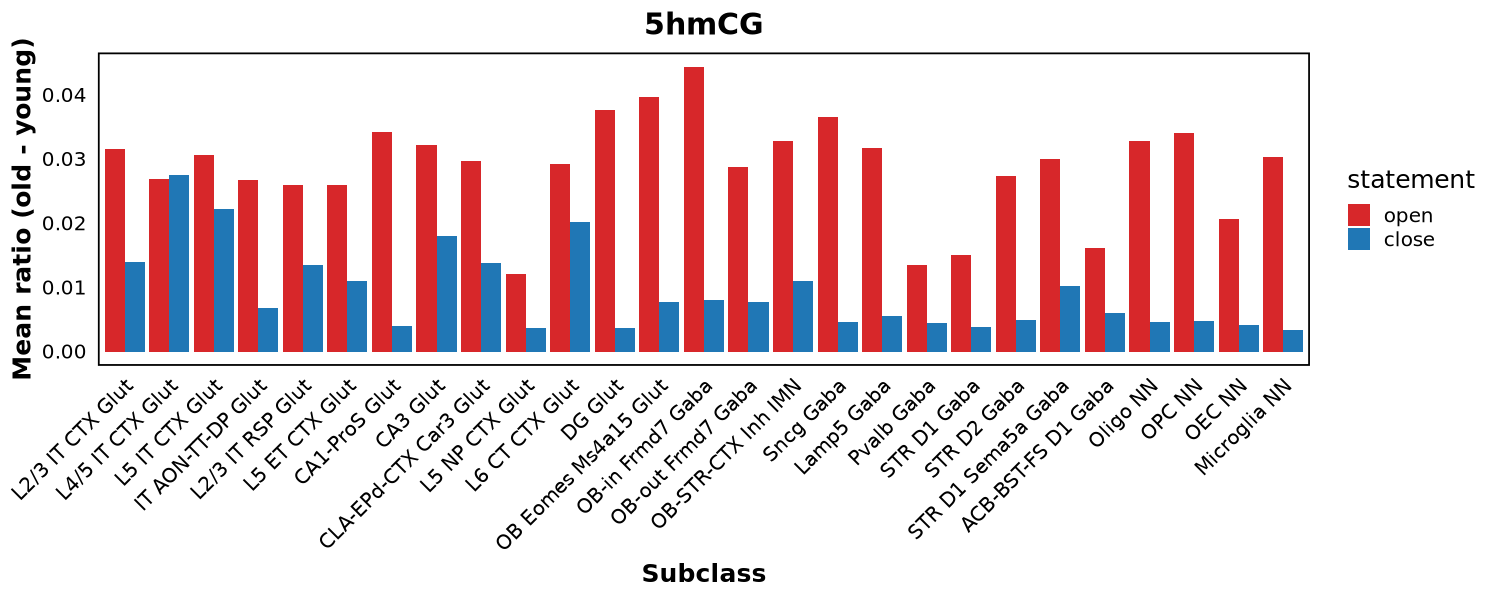

In [23]:
# options(repr.plot.width = 15, repr.plot.height = 6, repr.plot.res = 100)
# ggplot(hmCG_data, aes(x = subclass, y = mean_diff, fill = statement)) +
#   geom_bar(stat = "identity", position = position_dodge()) + 
#   labs(x = "Subclass", y = "Mean ratio (old - young)", title = "5hmCG") +
#   theme_minimal(base_size = 18) +
#   theme(
#     panel.grid = element_blank(),
#     panel.border = element_rect(color = "black", fill = NA, size = 1.2),
#     axis.text = element_text(color = "black"),
#     axis.text.x = element_text(angle = 45, hjust = 1),
#     axis.title = element_text(face = "bold"),
#     plot.title = element_text(hjust = 0.5, face = "bold")
#   ) +
#   scale_fill_manual(values = c("open" = "#D7272A", "close" = "#2077B5"))

Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


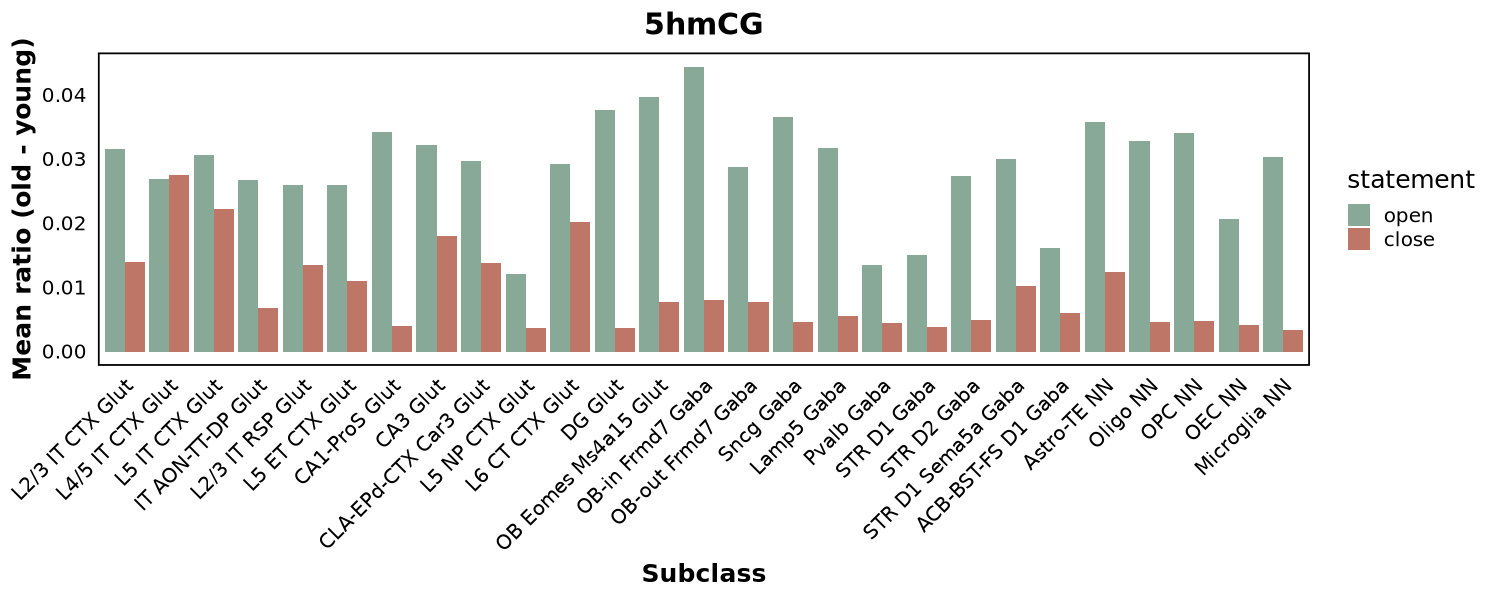

In [23]:
options(repr.plot.width = 15, repr.plot.height = 6, repr.plot.res = 100)
ggplot(hmCG_data, aes(x = subclass, y = mean_diff, fill = statement)) +
  geom_bar(stat = "identity", position = position_dodge()) + 
  labs(x = "Subclass", y = "Mean ratio (old - young)", title = "5hmCG") +
  theme_minimal(base_size = 18) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(hjust = 0.5, face = "bold")
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767"))

In [24]:
p1 <- ggplot(hmCG_data, aes(x = subclass, y = mean_diff, fill = statement)) +
  geom_bar(stat = "identity", position = position_dodge()) + 
  labs(x = "Subclass", y = "Mean ratio (old - young)", title = "5hmCG") +
  theme_minimal(base_size = 18) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(hjust = 0.5, face = "bold")
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767"))

In [25]:
mCG_data <- subset(result, modification == "mCG")

In [26]:
mCG_data

,subclass,mean_diff,modification,statement
,<fct>,<dbl>,<chr>,<fct>
55,ACB-BST-FS D1 Gaba,0.011774712,mCG,close
56,Astro-TE NN,0.024684380,mCG,close
57,CA1-ProS Glut,0.014663881,mCG,close
58,CA3 Glut,0.002887581,mCG,close
59,CLA-EPd-CTX Car3 Glut,0.012968295,mCG,close
60,DG Glut,0.009668729,mCG,close
61,IT AON-TT-DP Glut,0.015851843,mCG,close
62,L2/3 IT CTX Glut,0.013733386,mCG,close
63,L2/3 IT RSP Glut,0.013494984,mCG,close


In [27]:
levels(mCG_data$statement)

[1] "open"  "close"

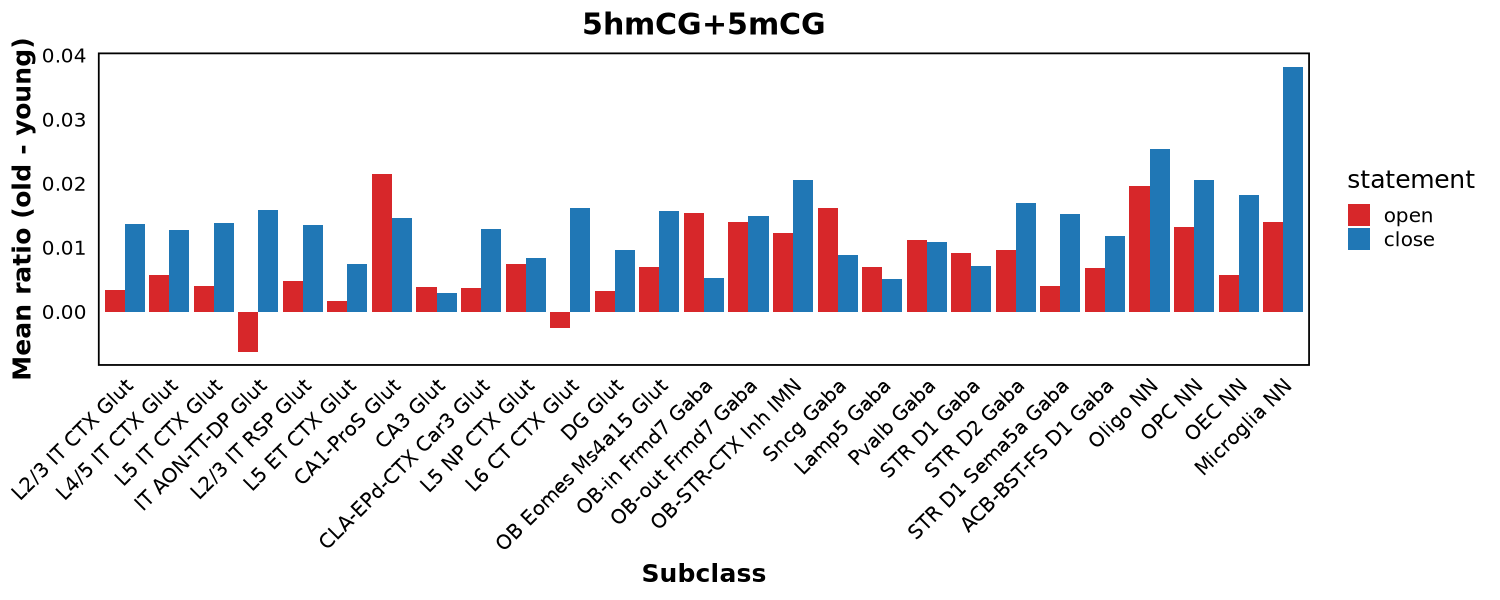

In [28]:
# options(repr.plot.width = 15, repr.plot.height = 6, repr.plot.res = 100)
# ggplot(mCG_data, aes(x = subclass, y = mean_diff, fill = statement)) +
#   geom_bar(stat = "identity", position = position_dodge()) + 
#   labs(x = "Subclass", y = "Mean ratio (old - young)", title = "5hmCG+5mCG") +
#   theme_minimal(base_size = 18) +
#   theme(
#     panel.grid = element_blank(),
#     panel.border = element_rect(color = "black", fill = NA, size = 1.2),
#     axis.text = element_text(color = "black"),
#     axis.text.x = element_text(angle = 45, hjust = 1),
#     axis.title = element_text(face = "bold"),
#     plot.title = element_text(hjust = 0.5, face = "bold")
#   ) +
#   scale_fill_manual(values = c("open" = "#D7272A", "close" = "#2077B5"))

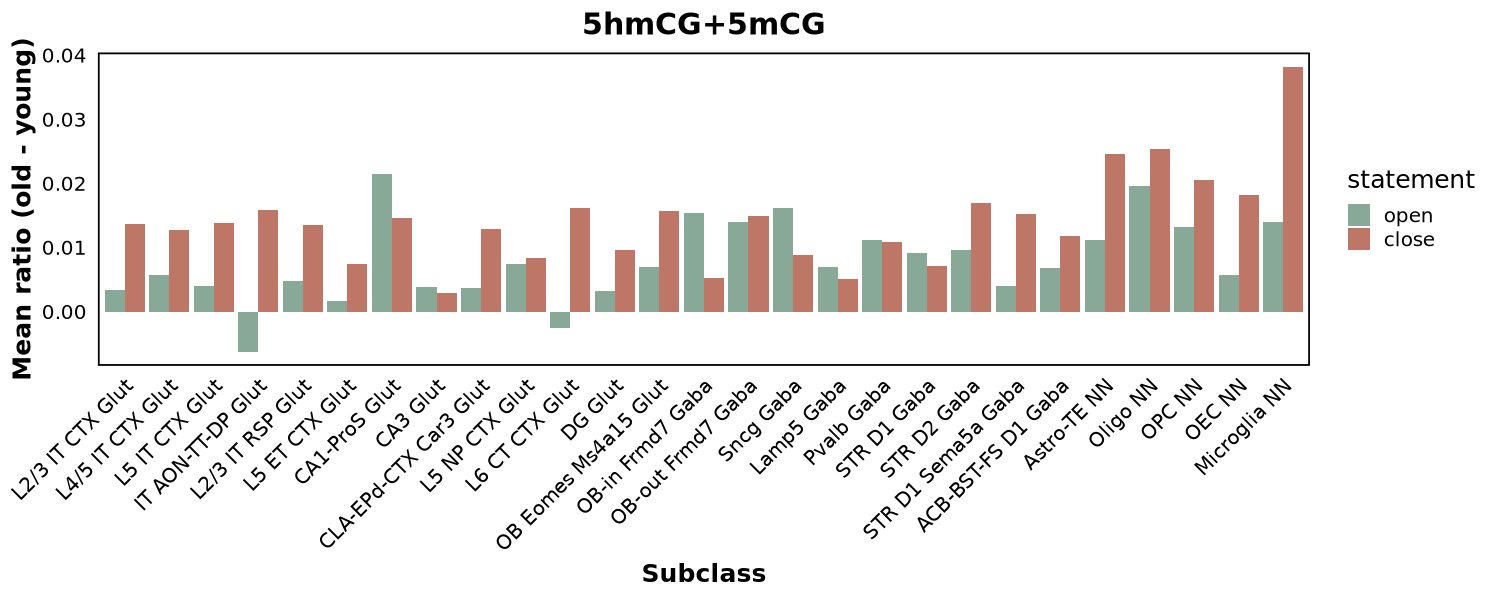

In [28]:
options(repr.plot.width = 15, repr.plot.height = 6, repr.plot.res = 100)
ggplot(mCG_data, aes(x = subclass, y = mean_diff, fill = statement)) +
  geom_bar(stat = "identity", position = position_dodge()) + 
  labs(x = "Subclass", y = "Mean ratio (old - young)", title = "5hmCG+5mCG") +
  theme_minimal(base_size = 18) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(hjust = 0.5, face = "bold")
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767"))

In [29]:
p2 <- ggplot(mCG_data, aes(x = subclass, y = mean_diff, fill = statement)) +
  geom_bar(stat = "identity", position = position_dodge()) + 
  labs(x = "Subclass", y = "Mean ratio (old - young)", title = "5hmCG+5mCG") +
  theme_minimal(base_size = 18) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(hjust = 0.5, face = "bold")
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767"))

In [30]:
library(dplyr)

In [ ]:
dir_mCG_open <- paste0(indir,"/01_mCG_open_peak/")
dir_hmCG_open <- paste0(indir,"/01_hmCG_open_peak/")
dir_mCG_close <- paste0(indir,"/01_mCG_close_peak/")
dir_hmCG_close <- paste0(indir,"/01_hmCG_close_peak/")

In [32]:
files_mCG_open <- list.files(dir_mCG_open, pattern = "5mCG\\.mm10\\.tmp$", full.names = TRUE)
files_hmCG_open <- list.files(dir_hmCG_open, pattern = "5hmCG\\.mm10\\.tmp$", full.names = TRUE)
files_mCG_close <- list.files(dir_mCG_close, pattern = "5mCG\\.mm10\\.tmp$", full.names = TRUE)
files_hmCG_close <- list.files(dir_hmCG_close, pattern = "5hmCG\\.mm10\\.tmp$", full.names = TRUE)

In [33]:
files_mCG_open;files_hmCG_open;files_mCG_close;files_hmCG_close

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//ACB-BST-FS.D1.Gaba_old_5mCG.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//ACB-BST-FS.D1.Gaba_young_5mCG.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//Astro-TE.NN_old_5mCG.mm10.tmp"            
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//Astro-TE.NN_young_5mCG.mm10.tmp"          
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//CA1-ProS.Glut_old_5mCG.mm10.tmp"          
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//CA1-ProS.Glut_young_5mCG.mm10.tmp"        
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//CA3.Glut_old_5mCG.mm10.tmp"               
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//CA3.Glut_young_5mCG.mm10.tmp"             
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//CLA-EPd-CTX.Car3.Glut_old_5mCG.mm10.tmp"  
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//CLA-EPd-CTX.Car3.Glut_young_5mCG.mm10.tmp"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//DG.Glut_old_5mCG.mm10.tmp"                
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//DG.Glut_young_5mCG.mm10.tmp"              
[13] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//IT.AON-TT-DP.Glut_old_5mCG.mm10.tmp"      
[14] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//IT.AON-TT-DP.Glut_young_5mCG.mm10.tmp"    
[15] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//L2.3.IT.CTX.Glut_old_5mCG.mm10.tmp"       
[16] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//L2.3.IT.CTX.Glut_young_5mCG.mm10.tmp"     
[17] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//L2.3.IT.RSP.Glut_old_5mCG.mm10.tmp"       
[18] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//L2.3.IT.RSP.Glut_young_5mCG.mm10.tmp"     
[19] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//L4.5.IT.CTX.Glut_old_5mCG.mm10.tmp"       
[20] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//L4.5.IT.CTX.Glut_young_5mCG.mm10.tmp"     
[21] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//L5.ET.CTX.Glut_old_5mCG.mm10.tmp"         
[22] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//L5.ET.CTX.Glut_young_5mCG.mm10.tmp"       
[23] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//L5.IT.CTX.Glut_old_5mCG.mm10.tmp"         
[24] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//L5.IT.CTX.Glut_young_5mCG.mm10.tmp"       
[25] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_open_peak//L5.NP.CTX.Glut_old_5mCG.mm10.tmp"         
[26] "/share/analysisdata/

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//ACB-BST-FS.D1.Gaba_old_5hmCG.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//ACB-BST-FS.D1.Gaba_young_5hmCG.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//Astro-TE.NN_old_5hmCG.mm10.tmp"            
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//Astro-TE.NN_young_5hmCG.mm10.tmp"          
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//CA1-ProS.Glut_old_5hmCG.mm10.tmp"          
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//CA1-ProS.Glut_young_5hmCG.mm10.tmp"        
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//CA3.Glut_old_5hmCG.mm10.tmp"               
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//CA3.Glut_young_5hmCG.mm10.tmp"             
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//CLA-EPd-CTX.Car3.Glut_old_5hmCG.mm10.tmp"  
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//CLA-EPd-CTX.Car3.Glut_young_5hmCG.mm10.tmp"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//DG.Glut_old_5hmCG.mm10.tmp"                
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//DG.Glut_young_5hmCG.mm10.tmp"              
[13] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//IT.AON-TT-DP.Glut_old_5hmCG.mm10.tmp"      
[14] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//IT.AON-TT-DP.Glut_young_5hmCG.mm10.tmp"    
[15] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//L2.3.IT.CTX.Glut_old_5hmCG.mm10.tmp"       
[16] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//L2.3.IT.CTX.Glut_young_5hmCG.mm10.tmp"     
[17] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//L2.3.IT.RSP.Glut_old_5hmCG.mm10.tmp"       
[18] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//L2.3.IT.RSP.Glut_young_5hmCG.mm10.tmp"     
[19] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//L4.5.IT.CTX.Glut_old_5hmCG.mm10.tmp"       
[20] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//L4.5.IT.CTX.Glut_young_5hmCG.mm10.tmp"     
[21] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//L5.ET.CTX.Glut_old_5hmCG.mm10.tmp"         
[22] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//L5.ET.CTX.Glut_young_5hmCG.mm10.tmp"       
[23] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//L5.IT.CTX.Glut_old_5hmCG.mm10.tmp"         
[24] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//L5.IT.CTX.Glut_young_5hmCG.mm10.tmp"       
[25] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_open_peak//L5.NP.CTX.Glut_old_5

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//ACB-BST-FS.D1.Gaba_old_5mCG.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//ACB-BST-FS.D1.Gaba_young_5mCG.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//Astro-TE.NN_old_5mCG.mm10.tmp"            
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//Astro-TE.NN_young_5mCG.mm10.tmp"          
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//CA1-ProS.Glut_old_5mCG.mm10.tmp"          
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//CA1-ProS.Glut_young_5mCG.mm10.tmp"        
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//CA3.Glut_old_5mCG.mm10.tmp"               
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//CA3.Glut_young_5mCG.mm10.tmp"             
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//CLA-EPd-CTX.Car3.Glut_old_5mCG.mm10.tmp"  
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//CLA-EPd-CTX.Car3.Glut_young_5mCG.mm10.tmp"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//DG.Glut_old_5mCG.mm10.tmp"                
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//DG.Glut_young_5mCG.mm10.tmp"              
[13] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//IT.AON-TT-DP.Glut_old_5mCG.mm10.tmp"      
[14] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//IT.AON-TT-DP.Glut_young_5mCG.mm10.tmp"    
[15] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//L2.3.IT.CTX.Glut_old_5mCG.mm10.tmp"       
[16] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//L2.3.IT.CTX.Glut_young_5mCG.mm10.tmp"     
[17] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//L2.3.IT.RSP.Glut_old_5mCG.mm10.tmp"       
[18] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//L2.3.IT.RSP.Glut_young_5mCG.mm10.tmp"     
[19] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//L4.5.IT.CTX.Glut_old_5mCG.mm10.tmp"       
[20] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//L4.5.IT.CTX.Glut_young_5mCG.mm10.tmp"     
[21] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//L5.ET.CTX.Glut_old_5mCG.mm10.tmp"         
[22] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//L5.ET.CTX.Glut_young_5mCG.mm10.tmp"       
[23] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//L5.IT.CTX.Glut_old_5mCG.mm10.tmp"         
[24] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//L5.IT.CTX.Glut_young_5mCG.mm10.tmp"       
[25] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_mCG_close_peak//L5.NP.CTX.Glut_old_5mCG.mm10.tmp"         
[

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//ACB-BST-FS.D1.Gaba_old_5hmCG.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//ACB-BST-FS.D1.Gaba_young_5hmCG.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//Astro-TE.NN_old_5hmCG.mm10.tmp"            
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//Astro-TE.NN_young_5hmCG.mm10.tmp"          
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//CA1-ProS.Glut_old_5hmCG.mm10.tmp"          
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//CA1-ProS.Glut_young_5hmCG.mm10.tmp"        
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//CA3.Glut_old_5hmCG.mm10.tmp"               
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//CA3.Glut_young_5hmCG.mm10.tmp"             
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//CLA-EPd-CTX.Car3.Glut_old_5hmCG.mm10.tmp"  
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//CLA-EPd-CTX.Car3.Glut_young_5hmCG.mm10.tmp"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//DG.Glut_old_5hmCG.mm10.tmp"                
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//DG.Glut_young_5hmCG.mm10.tmp"              
[13] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//IT.AON-TT-DP.Glut_old_5hmCG.mm10.tmp"      
[14] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//IT.AON-TT-DP.Glut_young_5hmCG.mm10.tmp"    
[15] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//L2.3.IT.CTX.Glut_old_5hmCG.mm10.tmp"       
[16] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//L2.3.IT.CTX.Glut_young_5hmCG.mm10.tmp"     
[17] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//L2.3.IT.RSP.Glut_old_5hmCG.mm10.tmp"       
[18] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//L2.3.IT.RSP.Glut_young_5hmCG.mm10.tmp"     
[19] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//L4.5.IT.CTX.Glut_old_5hmCG.mm10.tmp"       
[20] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//L4.5.IT.CTX.Glut_young_5hmCG.mm10.tmp"     
[21] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//L5.ET.CTX.Glut_old_5hmCG.mm10.tmp"         
[22] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//L5.ET.CTX.Glut_young_5hmCG.mm10.tmp"       
[23] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//L5.IT.CTX.Glut_old_5hmCG.mm10.tmp"         
[24] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_peak//L5.IT.CTX.Glut_young_5hmCG.mm10.tmp"       
[25] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/old_young/ATAC_latest_20250216/output/01_hmCG_close_p

In [34]:
process_files <- function(files1, files2) {
  result_list <- list()
  
  for (file1 in files1) {
    
    file_name <- basename(file1)
    corresponding_file <- files2[grepl(gsub("5mC", "5hmC", file_name), files2)]
    
    if (length(corresponding_file) == 1) {

      data1 <- read.table(file1, header = TRUE, stringsAsFactors = FALSE)
#       print(head(data1))
      data2 <- read.table(corresponding_file, header = TRUE, stringsAsFactors = FALSE)
#       print(head(data2))

      data1 <- data1[!is.na(data1[, 2]), ]
      data2 <- data2[!is.na(data2[, 2]), ]
      common_ids <- intersect(data1[, 1], data2[, 1])
      data1 <- data1[data1[, 1] %in% common_ids, ]
      data2 <- data2[data2[, 1] %in% common_ids, ]
      data1 <- data1[match(common_ids, data1[, 1]), ]
      data2 <- data2[match(common_ids, data2[, 1]), ]

      if (!identical(data1[, 1], data2[, 1])) {
        stop(paste("The first columns of", file1, "and", corresponding_file, "are not identical"))
      }

      diff <- data1[, 2] - data2[, 2]
      diff[diff < 0] <- 0
      avg_diff <- mean(diff, na.rm = TRUE)

      subclass <- gsub("_5mC.*$", "", file_name) %>% gsub("_(old|young)","",.)
      age_group <- ifelse(grepl("young", file_name), "young", "old")

      result_list[[file_name]] <- data.frame(Subclass = subclass,
                                             Age_Group = age_group,
                                             Difference = avg_diff)
    }
  }

  bind_rows(result_list)
}

In [35]:
result_open <- process_files(files_mCG_open, files_hmCG_open)
result_close <- process_files(files_mCG_close, files_hmCG_close)

In [36]:
result_open;result_close

Subclass,Age_Group,Difference
<chr>,<chr>,<dbl>
ACB-BST-FS.D1.Gaba,old,0.4468110
ACB-BST-FS.D1.Gaba,young,0.4560282
Astro-TE.NN,old,0.5105453
Astro-TE.NN,young,0.5349914
CA1-ProS.Glut,old,0.4202252
CA1-ProS.Glut,young,0.4329296
CA3.Glut,old,0.4277173
CA3.Glut,young,0.4560754
CLA-EPd-CTX.Car3.Glut,old,0.4258698


Subclass,Age_Group,Difference
<chr>,<chr>,<dbl>
ACB-BST-FS.D1.Gaba,old,0.7706892
ACB-BST-FS.D1.Gaba,young,0.7655371
Astro-TE.NN,old,0.6892906
Astro-TE.NN,young,0.6771481
CA1-ProS.Glut,old,0.7714178
CA1-ProS.Glut,young,0.7605308
CA3.Glut,old,0.7347563
CA3.Glut,young,0.7498771
CLA-EPd-CTX.Car3.Glut,old,0.7650499


In [37]:
library(tidyr)

In [38]:
final_result <- bind_rows(
  result_open %>% mutate(Type = "open"),
  result_close %>% mutate(Type = "close")
) %>%
  pivot_wider(names_from = Age_Group, values_from = Difference) %>% 
  mutate(Old_Young_Diff = old - young) ## %>%  
#   select(Subclass, Old_Young_Diff) 

In [39]:
final_result

Subclass,Type,old,young,Old_Young_Diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ACB-BST-FS.D1.Gaba,open,0.4468110,0.4560282,-0.0092172786
Astro-TE.NN,open,0.5105453,0.5349914,-0.0244460463
CA1-ProS.Glut,open,0.4202252,0.4329296,-0.0127043320
CA3.Glut,open,0.4277173,0.4560754,-0.0283581153
CLA-EPd-CTX.Car3.Glut,open,0.4258698,0.4518058,-0.0259359156
DG.Glut,open,0.4344394,0.4688430,-0.0344036571
IT.AON-TT-DP.Glut,open,0.4218431,0.4547428,-0.0328997471
L2.3.IT.CTX.Glut,open,0.4302996,0.4584029,-0.0281032152
L2.3.IT.RSP.Glut,open,0.3731321,0.3941791,-0.0210469955


In [40]:
unique(final_result$Subclass)

[1] "ACB-BST-FS.D1.Gaba"    "Astro-TE.NN"           "CA1-ProS.Glut"        
 [4] "CA3.Glut"              "CLA-EPd-CTX.Car3.Glut" "DG.Glut"              
 [7] "IT.AON-TT-DP.Glut"     "L2.3.IT.CTX.Glut"      "L2.3.IT.RSP.Glut"     
[10] "L4.5.IT.CTX.Glut"      "L5.ET.CTX.Glut"        "L5.IT.CTX.Glut"       
[13] "L5.NP.CTX.Glut"        "L6.CT.CTX.Glut"        "Lamp5.Gaba"           
[16] "Microglia.NN"          "OB-in.Frmd7.Gaba"      "OB-out.Frmd7.Gaba"    
[19] "OB.Eomes.Ms4a15.Glut"  "OEC.NN"                "Oligo.NN"             
[22] "OPC.NN"                "Pvalb.Gaba"            "Sncg.Gaba"            
[25] "STR.D1.Gaba"           "STR.D1.Sema5a.Gaba"    "STR.D2.Gaba"

In [41]:
subclass_info

subclass_v1,subclass_v2
<chr>,<chr>
ACB-BST-FS.D1.Gaba,ACB-BST-FS D1 Gaba
Astro-TE.NN,Astro-TE NN
CA1-ProS.Glut,CA1-ProS Glut
CA3.Glut,CA3 Glut
CLA-EPd-CTX.Car3.Glut,CLA-EPd-CTX Car3 Glut
DG.Glut,DG Glut
IT.AON-TT-DP.Glut,IT AON-TT-DP Glut
L2.3.IT.CTX.Glut,L2/3 IT CTX Glut
L2.3.IT.RSP.Glut,L2/3 IT RSP Glut


In [42]:
final_result$Subclass <- subclass_info$subclass_v2[match(final_result$Subclass,subclass_info$subclass_v1)]

In [43]:
final_result

Subclass,Type,old,young,Old_Young_Diff
<chr>,<chr>,<dbl>,<dbl>,<dbl>
ACB-BST-FS D1 Gaba,open,0.4468110,0.4560282,-0.0092172786
Astro-TE NN,open,0.5105453,0.5349914,-0.0244460463
CA1-ProS Glut,open,0.4202252,0.4329296,-0.0127043320
CA3 Glut,open,0.4277173,0.4560754,-0.0283581153
CLA-EPd-CTX Car3 Glut,open,0.4258698,0.4518058,-0.0259359156
DG Glut,open,0.4344394,0.4688430,-0.0344036571
IT AON-TT-DP Glut,open,0.4218431,0.4547428,-0.0328997471
L2/3 IT CTX Glut,open,0.4302996,0.4584029,-0.0281032152
L2/3 IT RSP Glut,open,0.3731321,0.3941791,-0.0210469955


In [44]:
final_result$Subclass <- factor(final_result$Subclass,levels = subclass_order)

In [45]:
levels(final_result$Subclass)

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "IT AON-TT-DP Glut"     "L2/3 IT RSP Glut"      "L5 ET CTX Glut"       
 [7] "CA1-ProS Glut"         "CA3 Glut"              "CLA-EPd-CTX Car3 Glut"
[10] "L5 NP CTX Glut"        "L6 CT CTX Glut"        "DG Glut"              
[13] "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"      "OB-out Frmd7 Gaba"    
[16] "Sncg Gaba"             "Lamp5 Gaba"            "Pvalb Gaba"           
[19] "STR D1 Gaba"           "STR D2 Gaba"           "STR D1 Sema5a Gaba"   
[22] "ACB-BST-FS D1 Gaba"    "Astro-TE NN"           "Oligo NN"             
[25] "OPC NN"                "OEC NN"                "Microglia NN"

In [46]:
final_result$Type <- factor(final_result$Type,levels = c("open","close"))

In [47]:
levels(final_result$Type)

[1] "open"  "close"

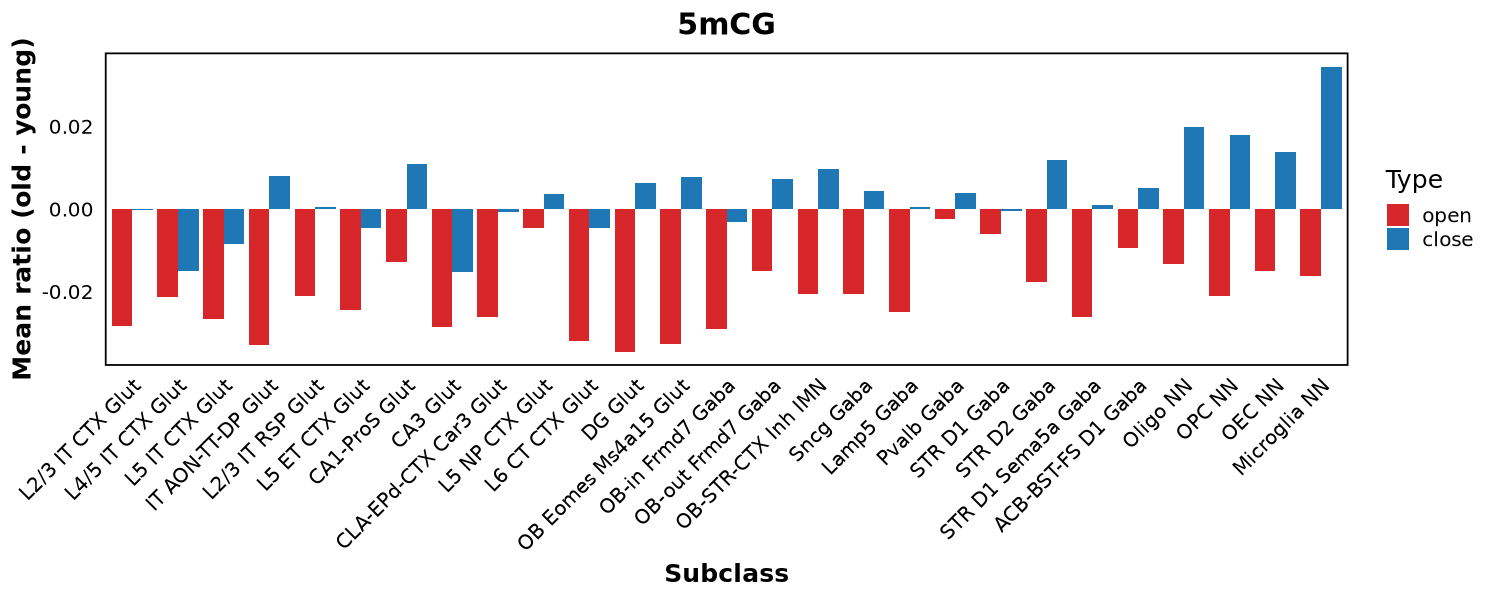

In [48]:
# options(repr.plot.width = 15, repr.plot.height = 6, repr.plot.res = 100)
# ggplot(final_result, aes(x = Subclass, y = Old_Young_Diff, fill = Type)) +
#   geom_bar(stat = "identity", position = position_dodge()) + 
#   labs(x = "Subclass", y = "Mean ratio (old - young)", title = "5mCG") +
#   theme_minimal(base_size = 18) +
#   theme(
#     panel.grid = element_blank(),
#     panel.border = element_rect(color = "black", fill = NA, size = 1.2),
#     axis.text = element_text(color = "black"),
#     axis.text.x = element_text(angle = 45, hjust = 1),
#     axis.title = element_text(face = "bold"),
#     plot.title = element_text(hjust = 0.5, face = "bold")
#   ) +
#   scale_fill_manual(values = c("open" = "#D7272A", "close" = "#2077B5"))

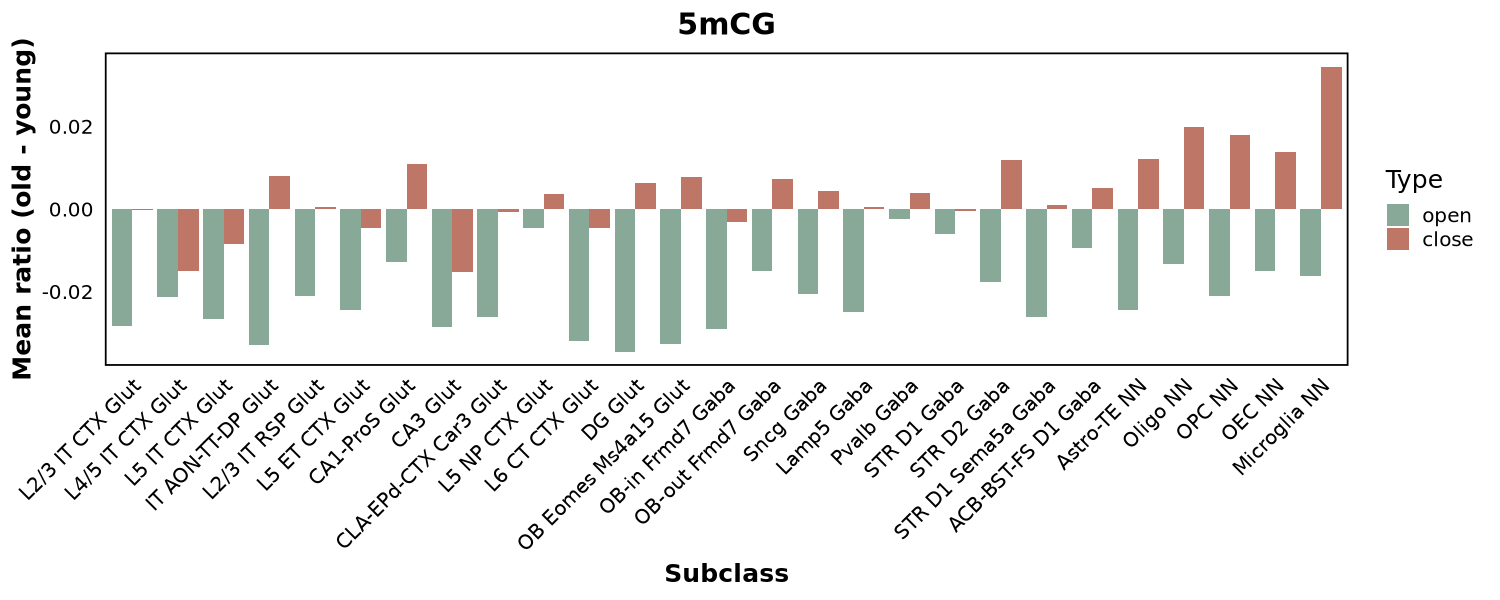

In [48]:
options(repr.plot.width = 15, repr.plot.height = 6, repr.plot.res = 100)
ggplot(final_result, aes(x = Subclass, y = Old_Young_Diff, fill = Type)) +
  geom_bar(stat = "identity", position = position_dodge()) + 
  labs(x = "Subclass", y = "Mean ratio (old - young)", title = "5mCG") +
  theme_minimal(base_size = 18) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(hjust = 0.5, face = "bold")
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767"))

In [49]:
p3 <- ggplot(final_result, aes(x = Subclass, y = Old_Young_Diff, fill = Type)) +
  geom_bar(stat = "identity", position = position_dodge()) + 
  labs(x = "Subclass", y = "Mean ratio (old - young)", title = "5mCG") +
  theme_minimal(base_size = 18) +
  theme(
    panel.grid = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, size = 1.2),
    axis.text = element_text(color = "black"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.title = element_text(face = "bold"),
    plot.title = element_text(hjust = 0.5, face = "bold")
  ) +
  scale_fill_manual(values = c("open" = "#88A997", "close" = "#BE7767"))

In [50]:
library(cowplot)
library(gridExtra)

Warning message:
“package ‘cowplot’ was built under R version 4.3.2”

Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine




In [51]:
g1 <- arrangeGrob(p1, heights = unit(6, "inches"), widths = unit(15, "inches"))
g2 <- arrangeGrob(p2, heights = unit(6, "inches"), widths = unit(15, "inches"))
g3 <- arrangeGrob(p3, heights = unit(6, "inches"), widths = unit(15, "inches"))

In [52]:
combined_plot <- arrangeGrob(g1, g2, g3, ncol = 3, nrow = 1)

In [ ]:
ggsave("../../../output/03-aging/06-ATAC/02-ATAC_open_close_peak_CG_methylation_ratio.pdf", combined_plot, width = 45, height = 6)